In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(
    "data set phishing websites.csv",
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

In [ ]:
print(df.shape)
print(df.columns)


(235749, 56)
Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmp

In [4]:
df = df.rename(columns={df.columns[-1]: "label"})
print(df.columns[-3:])

Index(['NoOfEmptyRef', 'NoOfExternalRef', 'label'], dtype='object')


In [5]:
print(df["label"].head(10))
print(df["label"].value_counts(dropna=False).head(20))

0    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
1    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
2    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
3    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
4    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
5    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
6    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
7    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
8    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
9    1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
Name: label, dtype: object
label
1;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;    134847
0;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;     99721
0;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;         328
0;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;           179
0;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;        127
0;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;

In [6]:
# clean the target values by extracting only 0 or 1
df["label"] = df["label"].astype(str).str.extract(r'([01])')[0]

# convert label to numeric
df["label"] = pd.to_numeric(df["label"], errors="coerce")

# remove rows where label is still missing
df = df.dropna(subset=["label"])

# convert to integer
df["label"] = df["label"].astype(int)

# check result
print(df["label"].head(10))
print(df["label"].value_counts(dropna=False))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: label, dtype: int64
label
1    134848
0    100901
Name: count, dtype: int64


In [7]:
#The target column was still not stored cleanly after import, because the class values contained trailing separator characters. Therefore, only the binary class value (0 or 1) was extracted from each label before converting the column to numeric format.

X = df.select_dtypes(include=[np.number]).drop(columns=["label"])
y = df["label"]

print("Number of features:", X.shape[1])
print(y.value_counts())

Number of features: 50
label
1    134848
0    100901
Name: count, dtype: int64


In [8]:
#The dataset was split into training and test sets using an 80/20 ratio. This is a common choice because it provides enough data for model training while reserving a meaningful portion for evaluation. A fixed random state of 42 was used to make the split reproducible, and stratified sampling was applied to preserve the class distribution in both subsets, which is important for imbalanced datasets like this one.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Training set shape: (188599, 50)
Test set shape: (47150, 50)

Training label distribution:
label
1    107878
0     80721
Name: count, dtype: int64

Test label distribution:
label
1    26970
0    20180
Name: count, dtype: int64


In [9]:
#This step trains the Gaussian Naive Bayes model on the training data. GaussianNB was selected because the dataset mainly contains numerical features such as counts, ratios, and scores, making it a suitable probabilistic baseline model.

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_gnb = gnb.predict(X_test)

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=== Gaussian Naive Bayes ===")
print("Accuracy :", accuracy_score(y_test, y_pred_gnb))
print("Precision:", precision_score(y_test, y_pred_gnb))
print("Recall   :", recall_score(y_test, y_pred_gnb))
print("F1-score :", f1_score(y_test, y_pred_gnb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_gnb))

=== Gaussian Naive Bayes ===
Accuracy : 0.9844114528101803
Precision: 0.9996191201675871
Recall   : 0.9731182795698925
F1-score : 0.9861906998590888

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     20180
           1       1.00      0.97      0.99     26970

    accuracy                           0.98     47150
   macro avg       0.98      0.99      0.98     47150
weighted avg       0.98      0.98      0.98     47150



In [ ]:
#This step trains Logistic Regression as a comparison model. A scaling step is included because Logistic Regression generally performs better when numerical features are standardized. This model is used to evaluate whether a more flexible linear classifier performs better than Gaussian Naive Bayes.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [ ]:
print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
##The extremely high performance of Logistic Regression suggests that the phishing and legitimate classes are highly separable in this dataset. However, these results should be interpreted with caution, since performance on one dataset does not automatically guarantee the same level of success in real-world settings.

=== Logistic Regression ===
Accuracy : 0.9998727465535525
Precision: 0.9997775800711743
Recall   : 1.0
F1-score : 0.9998887776665555

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20180
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47150
   macro avg       1.00      1.00      1.00     47150
weighted avg       1.00      1.00      1.00     47150



In [ ]:

results = pd.DataFrame({
    "Model": ["GaussianNB", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_lr)
    ],
    "Precision": [
        precision_score(y_test, y_pred_gnb),
        precision_score(y_test, y_pred_lr)
    ],
    "Recall": [
        recall_score(y_test, y_pred_gnb),
        recall_score(y_test, y_pred_lr)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_gnb),
        f1_score(y_test, y_pred_lr)
    ]
})

results.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
1,Logistic Regression,0.999873,0.999778,1.000000,0.999889
0,GaussianNB,0.984411,0.999619,0.973118,0.986191


#The Random Forest model was initialized with 200 trees to provide a stable ensemble without making computation unnecessarily expensive. A fixed random state of 42 was used to ensure reproducibility, and `n_jobs=-1` was set so that all available CPU cores could be used to speed up training. (Ai helped me understand this)


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [16]:
print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20180
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47150
   macro avg       1.00      1.00      1.00     47150
weighted avg       1.00      1.00      1.00     47150



In [18]:
#This step calculates feature importance values from the Random Forest model. These values show which variables contributed most strongly to the model’s predictions.

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

               Feature  Importance
3   URLSimilarityIndex    0.196128
49     NoOfExternalRef    0.167606
22          LineOfCode    0.134112
44           NoOfImage    0.111538
47         NoOfSelfRef    0.087300
46              NoOfJS    0.074356
36        HasSocialNet    0.032918
45             NoOfCSS    0.031414
32      HasDescription    0.023246
43    HasCopyrightInfo    0.022275


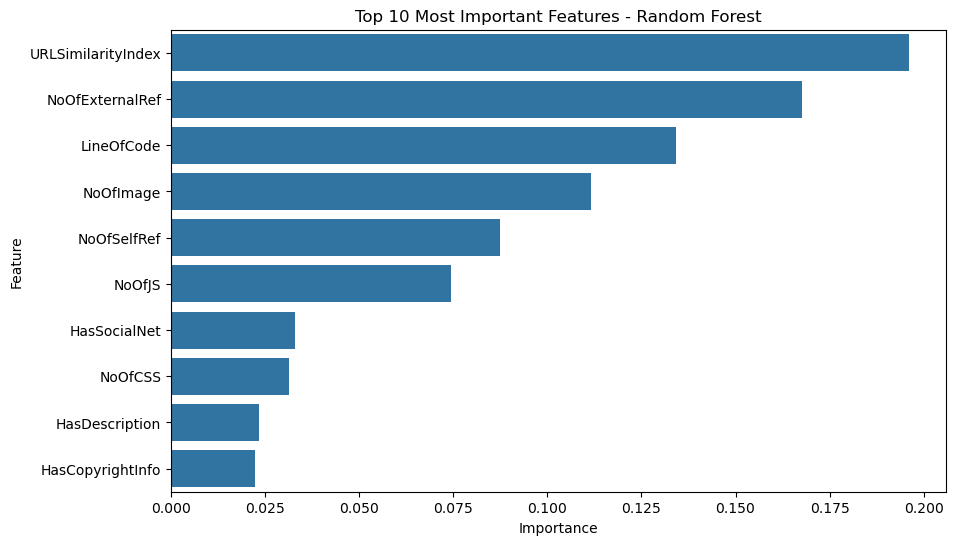

In [ ]:
#This plot visualizes the ten most important features identified by the Random Forest model. It helps interpret which website characteristics were most influential in phishing detection.The Random Forest model appears to rely most heavily on URL similarity, external references, and page structure variables. This indicates that phishing detection in this dataset is influenced not only by the URL itself, but also by the technical characteristics of the webpage.


plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Most Important Features - Random Forest")
plt.show()

In [20]:
# now it is time to analyse all three models and write a conclusion about the results. I will add confusin matrixes to see false positeves etc. and compare the results of each model.
results = pd.DataFrame({
    "Model": ["GaussianNB", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_gnb),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_gnb),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_gnb),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by="F1-score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,0.999873,0.999778,1.000000,0.999889
0,GaussianNB,0.984411,0.999619,0.973118,0.986191


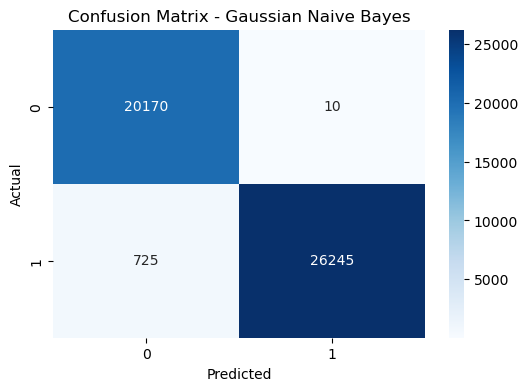

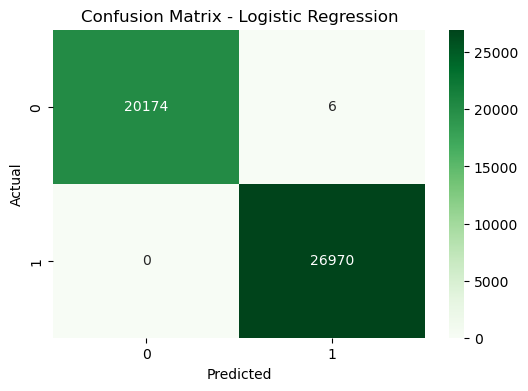

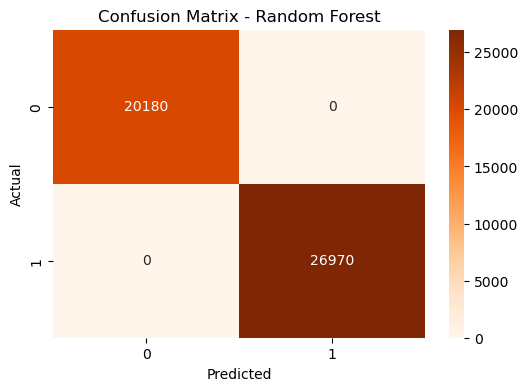

In [21]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#The confusion matrices provide a clearer view of the types of errors made by each model. Gaussian Naive Bayes performed well overall, but it produced 725 false negatives, meaning that 725 phishing websites were incorrectly classified as legitimate. In phishing detection, this is a serious weakness because false negatives can expose users to malicious websites.

#Logistic Regression performed much better in this respect. It produced no false negatives and only 6 false positives, meaning that it successfully detected all phishing websites in the test set while misclassifying only a very small number of legitimate websites.

#Random Forest achieved perfect classification on the test set, with zero false positives and zero false negatives. This indicates that, on this dataset, it was the strongest model. However, such perfect results should still be interpreted carefully, because performance on one dataset does not necessarily guarantee the same outcome in real-world settings.
#The confusion matrices provide a clearer view of the types of errors made by each model. Gaussian Naive Bayes performed well overall, but it produced 725 false negatives, meaning that 725 phishing websites were incorrectly classified as legitimate. In phishing detection, this is a serious weakness because false negatives can expose users to malicious websites.



These results are extremely good, especially for Logistic Regression and Random Forest. That could mean:

the dataset is very informative

the classes are strongly separable

or the task is easier on this dataset than in real life